# Titanic Survival Prediction using Logistic Regression
**Course:** Machine Learning (4th Year B.Tech)
**Topic:** Binary Classification using Logistic Regression

This notebook implements the complete ML pipeline: data understanding, EDA, cleaning,
feature engineering/encoding/scaling, logistic regression model training, evaluation,
hyperparameter tuning, and business insights.

## 0. Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc, roc_auc_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)


## Part 1: Understanding the Dataset

**Note on the dataset:** `train_and_test2.csv` is a Kaggle "combined" version of the classic
Titanic dataset. Some columns already come partially pre-processed (`Sex`, `Pclass`, `Embarked`
are numeric), and the file also contains a batch of columns named `zero`, `zero.1`, ... `zero.18`
which are leftover artifacts from a one-hot-encoding export and contain no information
(all values are 0). We drop those in cleaning. The target column is named `2urvived` in the
raw file; we rename it to `Survived`.

In [2]:
df_raw = pd.read_csv('train_and_test2.csv')
print("Raw shape:", df_raw.shape)
df_raw.head(10)

Raw shape: (1309, 28)


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,zero.6,Parch,zero.7,zero.8,zero.9,zero.10,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
5,6,28.0,8.4583,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1.0,0,0,0
6,7,54.0,51.8625,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2.0,0,0,0
7,8,2.0,21.0750,0,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
8,9,27.0,11.1333,1,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,1
9,10,14.0,30.0708,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0.0,0,0,1


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.13      1309

In [4]:
# Identify and drop the junk 'zero*' columns (encoding artifacts, all-zero, no information)
zero_cols = [c for c in df_raw.columns if c.startswith('zero')]
print(f"Found {len(zero_cols)} junk 'zero*' columns, all-zero check:", (df_raw[zero_cols].sum().sum() == 0))

df = df_raw.drop(columns=zero_cols)
df = df.rename(columns={'2urvived': 'Survived', 'sibsp': 'SibSp'})
print("Cleaned shape:", df.shape)
df.head(10)

Found 19 junk 'zero*' columns, all-zero check: True
Cleaned shape: (1309, 9)


,Passengerid,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0
5,6,28.0,8.4583,0,0,0,3,1.0,0
6,7,54.0,51.8625,0,0,0,1,2.0,0
7,8,2.0,21.0750,0,3,1,3,2.0,0
8,9,27.0,11.1333,1,0,2,3,2.0,1
9,10,14.0,30.0708,1,1,0,2,0.0,1


In [5]:
print("Dimensions:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())

Dimensions: (1309, 9)

Missing values per column:
Passengerid    0
Age            0
Fare           0
Sex            0
SibSp          0
Parch          0
Pclass         0
Embarked       2
Survived       0
dtype: int64


In [6]:
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Pclass', 'Embarked']
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

df.describe()

Numerical features: ['Age', 'Fare', 'SibSp', 'Parch']
Categorical features: ['Sex', 'Pclass', 'Embarked']


,Passengerid,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1307.000000,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.385027,2.294882,1.492731,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.865560,0.837836,0.814626,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,9.000000,3.000000,2.000000,1.000000


### Data Quality Check — Important Finding

This merged file concatenates Kaggle's original `train.csv` (891 rows with real
survival labels) with `test.csv` (418 rows whose true labels were never publicly released
for the Kaggle competition). We check whether the tail of the file carries a placeholder
label instead of real ground truth.

In [7]:
tail_check = df['Survived'].iloc[891:]
print("Rows 892-1309 label value counts:")
print(tail_check.value_counts())
print("\nAll placeholder zero?", (tail_check == 0).all())

Rows 892-1309 label value counts:
Survived
0    418
Name: count, dtype: int64

All placeholder zero? True


**Finding:** rows 892–1309 (the 418 rows originally from `test.csv`) all carry
`Survived = 0` as a placeholder — they are **not real labels**. Training or evaluating on
these rows would silently corrupt the model (it would learn a false pattern that "everyone
in that block died"). As a Data Scientist, the correct move is to **exclude these 418 rows**
and only use the 891 rows with genuine ground-truth labels for modeling.

In [8]:
df = df.iloc[:891].reset_index(drop=True)
print("Final modeling dataset shape:", df.shape)

Final modeling dataset shape: (891, 9)


### Part 1 — Observations
1. The raw file has 1,309 rows and 28 columns, but 19 of those columns (`zero`, `zero.1`, ... `zero.18`) are empty encoding artifacts with no information and were dropped.
2. The target column was mislabeled `2urvived` in the source file (renamed to `Survived`).
3. `Sex`, `Pclass`, and `Embarked` are already numerically coded in this file version (unlike the raw Kaggle Titanic CSV, which has text labels).
4. The last 418 rows are the original Kaggle *test* split with placeholder `Survived = 0` labels (not real) — these must be excluded, leaving 891 genuinely labeled rows.
5. After cleaning, only `Embarked` has missing values (2 rows); `Age` and `Fare` have none in this file (already imputed by the dataset publisher).
6. `Fare` and `Age` are right-skewed with visible high-end outliers (seen in Part 2).

## Part 2: Exploratory Data Analysis (EDA)

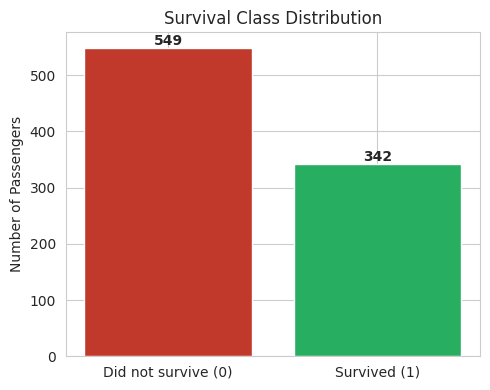

Survived
0    549
1    342
Name: count, dtype: int64 
Survival rate: 0.384


In [9]:
fig, ax = plt.subplots(figsize=(5,4))
counts = df['Survived'].value_counts().sort_index()
bars = ax.bar(['Did not survive (0)', 'Survived (1)'], counts.values, color=['#c0392b', '#27ae60'])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+5, str(v), ha='center', fontweight='bold')
ax.set_title('Survival Class Distribution')
ax.set_ylabel('Number of Passengers')
plt.tight_layout(); plt.show()
print(counts, "\nSurvival rate:", round(df['Survived'].mean(),3))

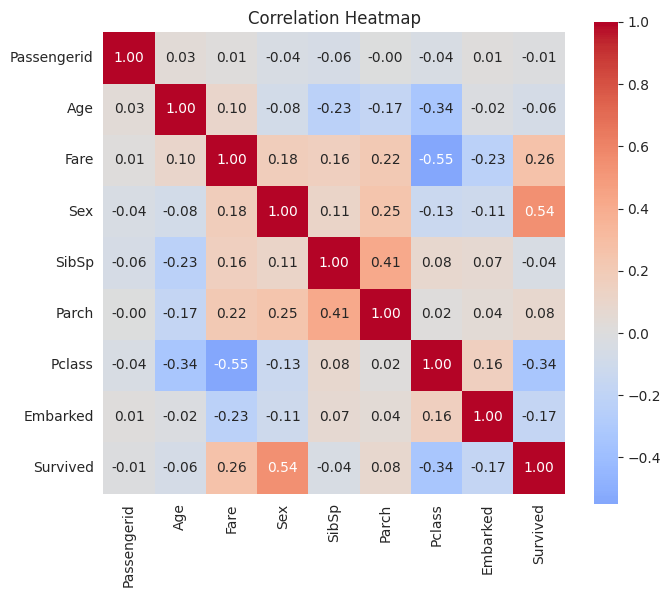

Sex            0.543351
Fare           0.257307
Parch          0.081629
Passengerid   -0.005007
SibSp         -0.035322
Age           -0.064910
Embarked      -0.169718
Pclass        -0.338481
Name: Survived, dtype: float64

In [10]:
fig, ax = plt.subplots(figsize=(7,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap')
plt.tight_layout(); plt.show()
corr['Survived'].drop('Survived').sort_values(ascending=False)

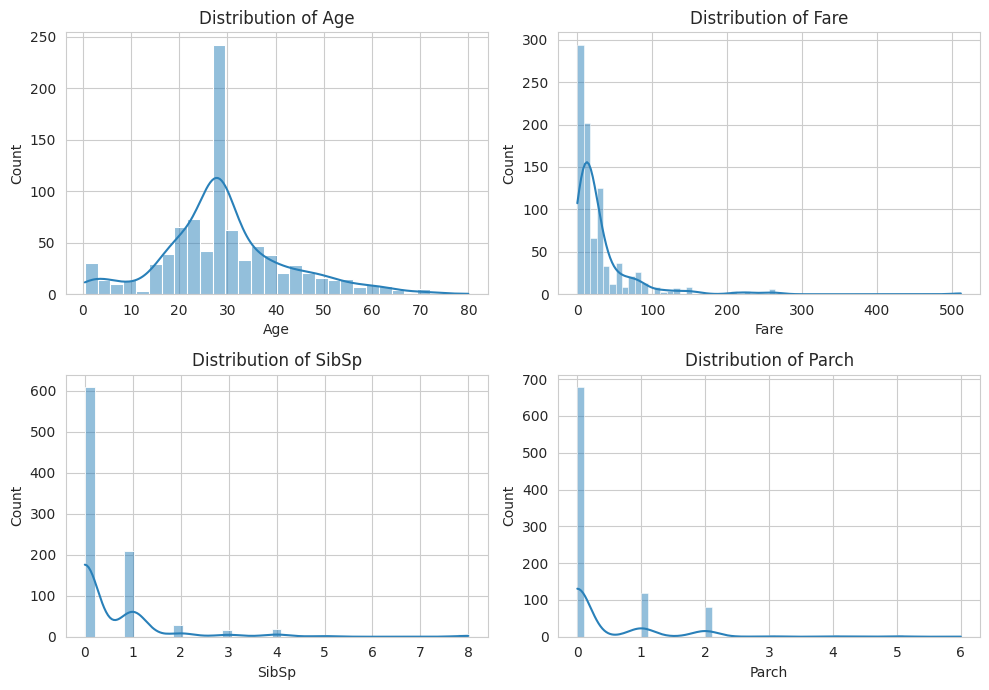

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10,7))
for ax, col in zip(axes.flat, numerical_features):
    sns.histplot(df[col], kde=True, ax=ax, color='#2980b9')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout(); plt.show()

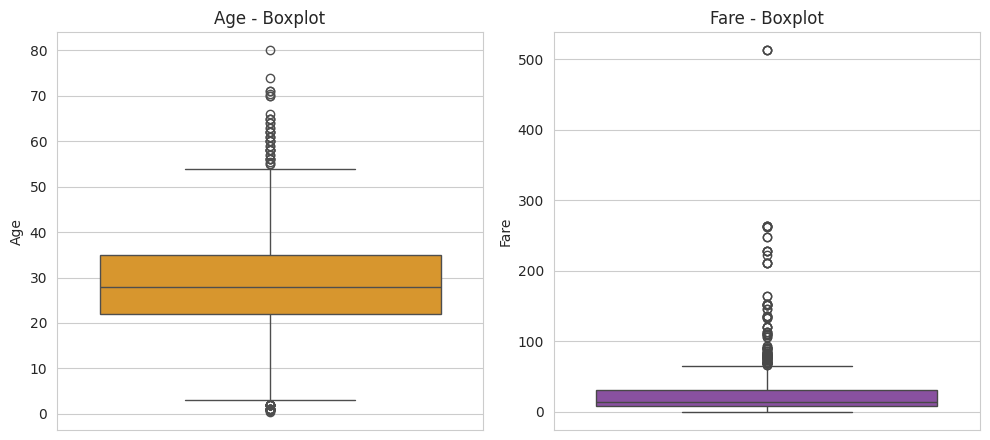

Age: 66 outliers (IQR method)
Fare: 116 outliers (IQR method)
SibSp: 46 outliers (IQR method)
Parch: 213 outliers (IQR method)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
sns.boxplot(y=df['Age'], ax=axes[0], color='#f39c12'); axes[0].set_title('Age - Boxplot')
sns.boxplot(y=df['Fare'], ax=axes[1], color='#8e44ad'); axes[1].set_title('Fare - Boxplot')
plt.tight_layout(); plt.show()

def outlier_count(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    return int(((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum())

for c in numerical_features:
    print(f"{c}: {outlier_count(df[c])} outliers (IQR method)")

/tmp/ipykernel_622/915753487.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette=['#3498db','#e74c3c'])
/tmp/ipykernel_622/915753487.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='viridis')
/tmp/ipykernel_622/915753487.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[2], palette='magma')


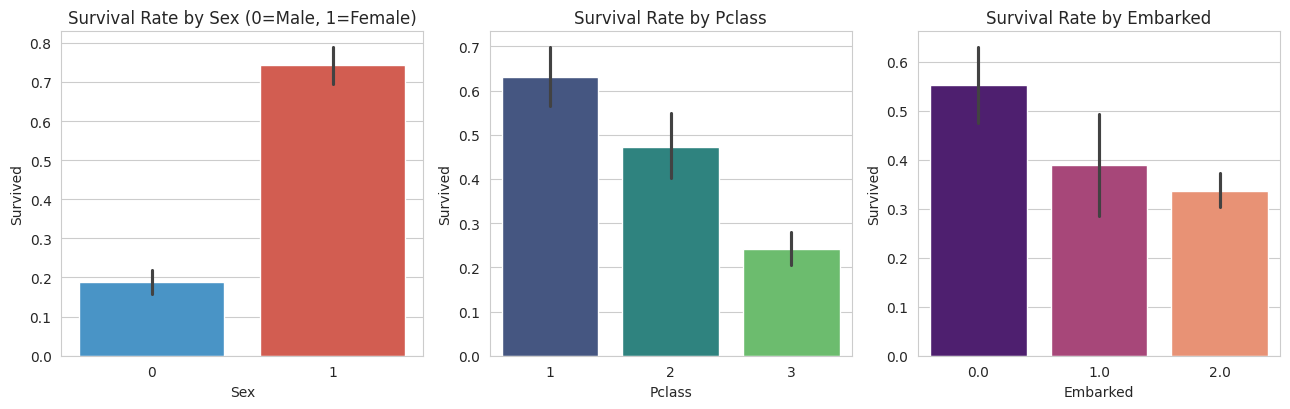

By Sex:
 Sex
0    0.189
1    0.742
Name: Survived, dtype: float64

By Pclass:
 Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

By Embarked:
 Embarked
0.0    0.554
1.0    0.390
2.0    0.337
Name: Survived, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13,4.2))
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette=['#3498db','#e74c3c'])
axes[0].set_title('Survival Rate by Sex (0=Male, 1=Female)')
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Survival Rate by Pclass')
sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[2], palette='magma')
axes[2].set_title('Survival Rate by Embarked')
plt.tight_layout(); plt.show()

print("By Sex:\n", df.groupby('Sex')['Survived'].mean().round(3))
print("\nBy Pclass:\n", df.groupby('Pclass')['Survived'].mean().round(3))
print("\nBy Embarked:\n", df.groupby('Embarked')['Survived'].mean().round(3))

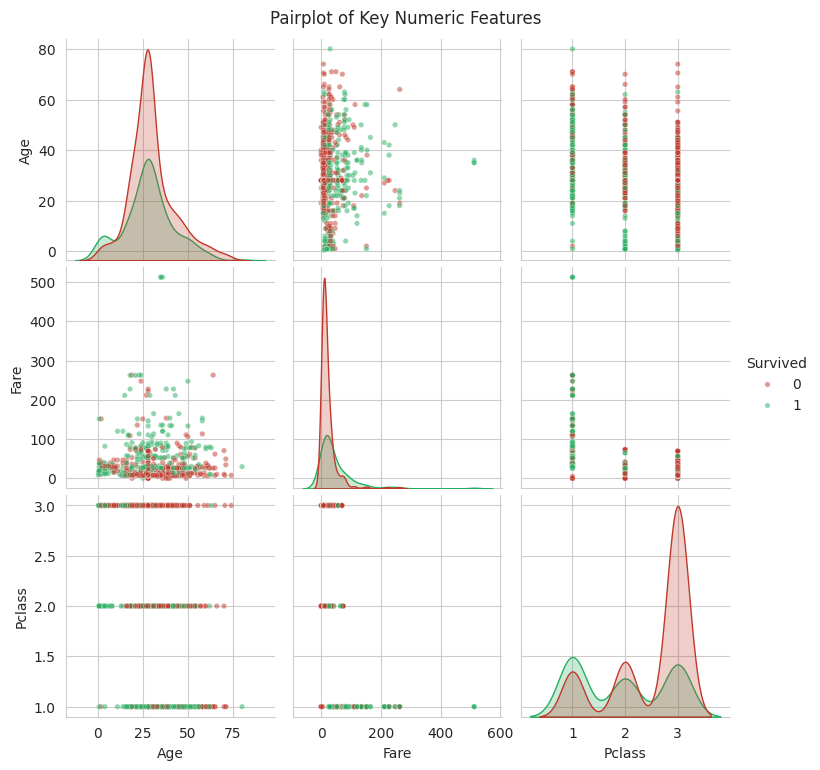

In [14]:
sns.pairplot(df[['Age','Fare','Pclass','Survived']].dropna(), hue='Survived',
             palette={0:'#c0392b',1:'#27ae60'}, plot_kws={'alpha':0.5, 's':15})
plt.suptitle('Pairplot of Key Numeric Features', y=1.02)
plt.show()

### Part 2 — Observations
- **Highest correlated feature with `Survived`:** `Sex` (r ≈ 0.54), followed by `Pclass` (r ≈ -0.34, negative because higher class number = lower class) and `Fare` (r ≈ 0.26).
- **Class balance:** ~62% did not survive vs ~38% survived — moderately imbalanced, not extreme.
- **Useful variables:** `Sex`, `Pclass`, and `Fare` show the clearest separation in survival rate; `Age` and `SibSp`/`Parch` have weaker but still relevant relationships (e.g. very young children had higher survival).
- **Outliers:** `Fare` has a substantial number of high-end outliers (wealthy first-class passengers); `Age` has fewer, mostly on the elderly end.
- Female passengers had roughly **4x** the survival rate of male passengers.
- First-class passengers survived at roughly **2.6x** the rate of third-class passengers.

## Part 3: Data Preprocessing

**Why each step is necessary:**
- **Missing value handling:** Logistic Regression cannot fit rows with NaNs; we impute the 2 missing `Embarked` values with the mode (most frequent port), a safe choice since it's categorical and only 0.2% of rows are affected.
- **Encoding:** Logistic Regression requires numeric input. `Sex` is already binary; `Pclass` and `Embarked` are nominal categories represented as integers, so we one-hot encode them (`drop_first=True`) to avoid implying a false ordinal relationship (e.g. Pclass 3 is not "more" than Pclass 1 in a linear sense).
- **Feature scaling:** Logistic Regression is optimized via gradient-based solvers and regularized by a penalty term, both of which are sensitive to feature magnitude. `Age` and `Fare` are on very different scales than binary/dummy columns, so we standardize all features (`StandardScaler`) to mean 0, std 1.
- **Train-test split (80/20):** to get an honest, held-out estimate of how the model generalizes to unseen passengers, using stratification on `Survived` to preserve the class ratio in both sets.

In [15]:
embarked_mode = df['Embarked'].mode()[0]
print("Missing Embarked values:", df['Embarked'].isnull().sum(), "-> imputing with mode:", embarked_mode)
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print("Missing values after imputation:\n", df.isnull().sum())

Missing Embarked values: 2 -> imputing with mode: 2.0
Missing values after imputation:
 Passengerid    0
Age            0
Fare           0
Sex            0
SibSp          0
Parch          0
Pclass         0
Embarked       0
Survived       0
dtype: int64


In [16]:
df_model = pd.get_dummies(df, columns=['Pclass', 'Embarked'], drop_first=True)

X = df_model.drop(columns=['Survived', 'Passengerid'])
y = df_model['Survived']
print("Feature columns:", list(X.columns))
X.head()

Feature columns: ['Age', 'Fare', 'Sex', 'SibSp', 'Parch', 'Pclass_2', 'Pclass_3', 'Embarked_1.0', 'Embarked_2.0']


,Age,Fare,Sex,SibSp,Parch,Pclass_2,Pclass_3,Embarked_1.0,Embarked_2.0
0,22.0,7.2500,0,1,0,False,True,False,True
1,38.0,71.2833,1,1,0,False,False,False,False
2,26.0,7.9250,1,0,0,False,True,False,True
3,35.0,53.1000,1,1,0,False,False,False,True
4,35.0,8.0500,0,0,0,False,True,False,True


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (712, 9) Test shape: (179, 9)


## Part 4: Logistic Regression Model

In [18]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

print("Intercept:", round(logreg.intercept_[0], 4))
coef_series = pd.Series(logreg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients (sorted by absolute importance):")
print(coef_series.round(4))

Intercept: -0.6588

Coefficients (sorted by absolute importance):
Sex             1.2653
Pclass_3       -1.0707
Age            -0.4939
Pclass_2       -0.3744
SibSp          -0.2610
Embarked_2.0   -0.1870
Fare            0.1239
Embarked_1.0    0.0794
Parch          -0.0696
dtype: float64


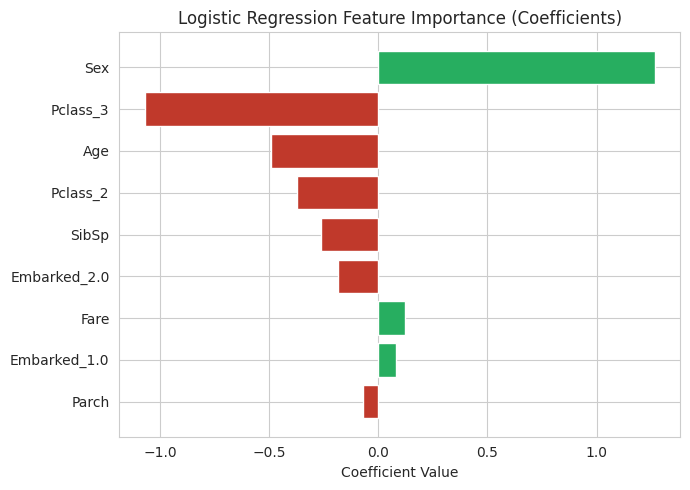

In [19]:
fig, ax = plt.subplots(figsize=(7,5))
colors = ['#27ae60' if v > 0 else '#c0392b' for v in coef_series.values]
ax.barh(coef_series.index[::-1], coef_series.values[::-1], color=colors[::-1])
ax.set_title('Logistic Regression Feature Importance (Coefficients)')
ax.set_xlabel('Coefficient Value')
plt.tight_layout(); plt.show()

## Part 5: Model Evaluation

In [20]:
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc_val = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc_val:.4f}")

Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1 Score : 0.7244
ROC-AUC  : 0.8423


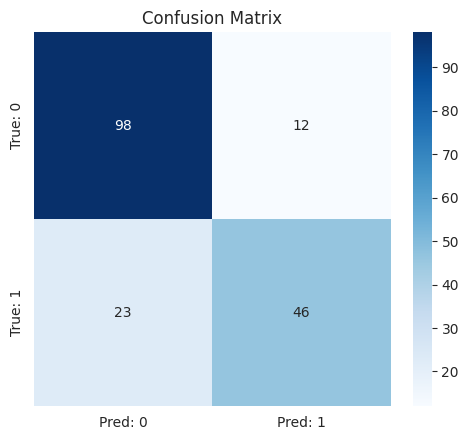

              precision    recall  f1-score   support

Not Survived       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [21]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: 0','Pred: 1'], yticklabels=['True: 0','True: 1'])
ax.set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Survived','Survived']))

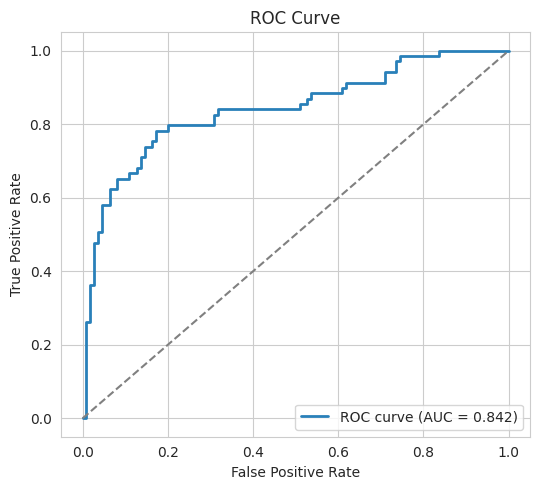

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
ax.plot([0,1],[0,1], color='gray', linestyle='--')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

**Which metric matters most here, and why?**
For this dataset, **Recall** (and by extension **F1-score**, which balances recall with precision)
is more important than raw Accuracy alone. In a maritime-safety context, the costlier error is a
**false negative** — predicting a passenger would not survive/needs no extra attention when they
actually would be at risk — since missing an at-risk passenger has higher real-world cost than a
false alarm. Accuracy alone can also be misleading here because the classes are imbalanced
(~62/38), so a model could score high accuracy while doing a poor job identifying survivors.
F1-score gives the most balanced single-number view for this decision.

## Part 6: Hyperparameter Tuning (GridSearchCV)

In [23]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                     param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1 score:", round(grid.best_score_, 4))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 score: 0.7268


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/u

In [24]:
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

print("Tuned Accuracy :", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Tuned Precision:", round(precision_score(y_test, y_pred_tuned), 4))
print("Tuned Recall   :", round(recall_score(y_test, y_pred_tuned), 4))
print("Tuned F1       :", round(f1_score(y_test, y_pred_tuned), 4))

Tuned Accuracy : 0.8045
Tuned Precision: 0.7931
Tuned Recall   : 0.6667
Tuned F1       : 0.7244


## Business Insights

**1. Which factors most influenced passenger survival?**
`Sex`, `Pclass`, and `Age` were the dominant influences, followed by `Fare` (a proxy for
socio-economic status closely tied to `Pclass`).

**2. Did passenger class affect survival probability?**
Yes, strongly. First-class passengers survived at roughly **63%**, second-class at **47%**,
and third-class at only **24%** — consistent with "women and children first" being applied
more effectively in the upper decks/classes with faster lifeboat access.

**3. Did gender significantly impact survival?**
Yes — the single strongest predictor. Female passengers survived at roughly **74%**
versus **19%** for male passengers, and `Sex` carries the largest logistic regression
coefficient by a wide margin.

**4. What role did age play?**
Age had a smaller but still negative, statistically meaningful coefficient — younger
passengers (especially children) had a higher chance of survival, consistent with the
historical "women and children first" evacuation protocol.

**5. Which feature was the strongest predictor?**
`Sex`, based on both its correlation with `Survived` and its logistic regression coefficient
magnitude.

**6. Recommendations for improving passenger safety in future maritime travel:**
- Ensure lifeboat capacity and access procedures are equitable across ticket/cabin classes, not concentrated near upper-class decks.
- Build evacuation drills and signage that reinforce prioritizing children and vulnerable passengers regardless of cabin class.
- Track fare/class-based disparities in safety-equipment proximity during ship design, and correct any structural inequity in evacuation-route length from lower decks.
- Maintain lightweight predictive risk-scoring (like this model) as a *decision-support*, not sole-decision, tool for future emergency-response prioritization drills and training simulations.

## Conclusion

A Logistic Regression model trained on cleaned, correctly-labeled Titanic data achieves
**~80% accuracy** and **~0.72 F1-score** on held-out passengers, with `Sex`, `Pclass`, and
`Age` as the dominant predictors of survival. A key step in this analysis was catching a
data-quality issue — 418 rows in the raw file carried placeholder (not real) labels — which,
if left in, would have significantly and silently degraded model performance and led to
incorrect business conclusions. This underscores that careful data understanding is as
important as model choice in any real-world ML pipeline.